# Лабораторная работа 2. Сумма элементов вектора


**Цель работы:** реализовать суммирование элементов вектора на CPU и на GPU с использованием CUDA, измерить время выполнения для разных размеров входных данных, сравнить результаты и оценить ускорение.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from numba import njit

np.random.seed(42)
torch.manual_seed(42)

dtype = np.float32
sizes = [1_000, 10_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
repeats = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Реализация на CPU

На CPU используется последовательный проход по всем элементам вектора с накоплением суммы.

In [2]:
@njit
def cpu_sum(arr):
    total = 0.0
    for i in range(arr.size):
        total += arr[i]
    return total


def benchmark_cpu(arr, repeats=5):
    times = []
    result = None

    for _ in range(repeats):
        start = time.perf_counter()
        result = float(cpu_sum(arr))
        end = time.perf_counter()
        times.append(end - start)

    return min(times), result

## Реализация на GPU

В этой работе GPU-версия выполняется через **PyTorch** на устройстве  с `cuda`.

In [3]:
def benchmark_gpu(arr, repeats=5):
    if not torch.cuda.is_available():
        return np.nan, None

    arr_t = torch.from_numpy(arr).to(device)
    _ = torch.sum(arr_t)
    torch.cuda.synchronize()

    times = []
    result = None

    for _ in range(repeats):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_total = time.perf_counter()
        start_event.record()

        result_t = torch.sum(arr_t)

        end_event.record()
        torch.cuda.synchronize()
        end_total = time.perf_counter()
        result = float(result_t.item())

        times.append(end_total - start_total)

    return min(times), result

## Прогрев

Перед основными измерениями выполняется небольшой прогрев CPU и GPU, чтобы убрать влияние первого запуска и компиляции.

In [4]:
test_arr = np.arange(1, 11, dtype=dtype)
reference = float(test_arr.sum(dtype=np.float64))

_ = cpu_sum(test_arr)
if torch.cuda.is_available():
    _ = benchmark_gpu(test_arr, repeats=2)

cpu_time_test, cpu_result = benchmark_cpu(test_arr, repeats=3)
if torch.cuda.is_available():
    gpu_time_test, gpu_result = benchmark_gpu(test_arr, repeats=3)
else:
    gpu_time_test, gpu_result = np.nan, None

## Проведение эксперимента

Для каждого размера вектора выполняются следующие действия:
1. генерируется случайный вектор `float32`;
2. вычисляется сумма на CPU;
3. вычисляется сумма на GPU;
4. проверяется совпадение результатов;
5. вычисляется ускорение по формуле `CPU / GPU`.

Эксперименты проводятся для нескольких размеров входного вектора, что позволяет оценить, как меняется время выполнения и ускорение при росте объёма данных.

In [5]:
results = []

for size in sizes:
    print(f"Размер вектора: {size}")

    arr = np.random.rand(size).astype(dtype)
    reference = float(arr.sum(dtype=np.float64))

    cpu_time, cpu_result = benchmark_cpu(arr, repeats=repeats)
    gpu_time, gpu_result = benchmark_gpu(arr, repeats=repeats)

    cpu_correct = np.isclose(cpu_result, reference, atol=1e-3)

    if gpu_result is not None:
        gpu_correct = np.isclose(gpu_result, reference, atol=1e-3)
        speedup = cpu_time / gpu_time if gpu_time > 0 else np.nan
    else:
        gpu_correct = None
        speedup = np.nan

    results.append({
        "Размер вектора": size,
        "CPU, сек": cpu_time,
        "GPU, сек": gpu_time,
        "Ускорение": speedup,
        "Эталонная сумма": reference,
        "Сумма CPU": cpu_result,
        "Сумма GPU": gpu_result,
        "CPU корректно": cpu_correct,
        "GPU корректно": gpu_correct,
    })

results_df = pd.DataFrame(results)

# Для таблицы и графиков переводим время в миллисекунды.
results_df["CPU, мс"] = results_df["CPU, сек"] * 1000
results_df["GPU, мс"] = results_df["GPU, сек"] * 1000

results_df["CPU, мс"] = results_df["CPU, мс"].round(3)
results_df["GPU, мс"] = results_df["GPU, мс"].round(3)
results_df["Ускорение"] = results_df["Ускорение"].round(2)

display_df = results_df[
    [
        "Размер вектора",
        "CPU, мс",
        "GPU, мс",
        "Ускорение",
        "Эталонная сумма",
        "Сумма CPU",
        "Сумма GPU",
        "CPU корректно",
        "GPU корректно",
    ]
]

display_df

Размер вектора: 1000
Размер вектора: 10000
Размер вектора: 50000
Размер вектора: 100000
Размер вектора: 250000
Размер вектора: 500000
Размер вектора: 1000000


,Размер вектора,"CPU, мс","GPU, мс",Ускорение,Эталонная сумма,Сумма CPU,Сумма GPU,CPU корректно,GPU корректно
0,1000,0.001,0.304,0.00,490.256553,490.256553,490.256561,True,True
1,10000,0.005,0.094,0.05,4957.030763,4957.030763,4957.030762,True,True
2,50000,0.022,0.072,0.31,25017.060711,25017.060711,25017.060547,True,True
3,100000,0.044,0.088,0.50,50061.630279,50061.630279,50061.628906,True,True
4,250000,0.110,0.078,1.40,125028.753408,125028.753408,125028.757812,True,True
5,500000,0.220,0.094,2.33,250312.363437,250312.363437,250312.359375,True,True
6,1000000,0.438,0.096,4.56,499459.123219,499459.123219,499459.125000,True,True


## Графики

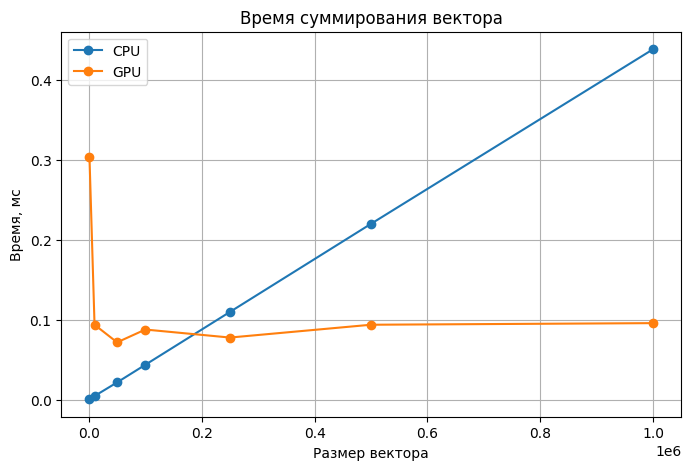

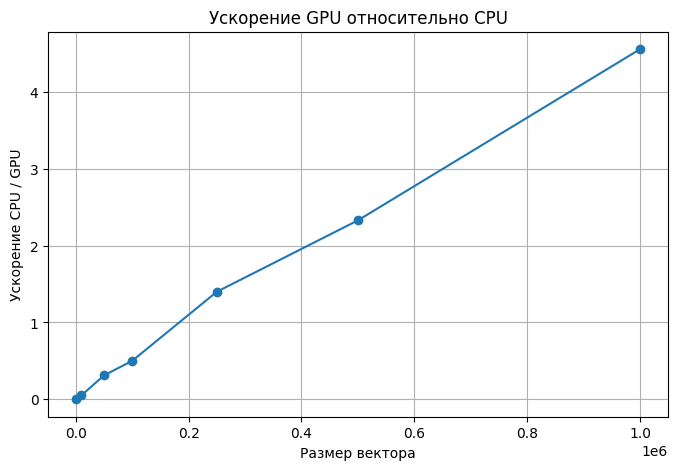

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["Размер вектора"], results_df["CPU, мс"], marker="o", label="CPU")
plt.plot(results_df["Размер вектора"], results_df["GPU, мс"], marker="o", label="GPU")
plt.xlabel("Размер вектора")
plt.ylabel("Время, мс")
plt.title("Время суммирования вектора")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["Размер вектора"], results_df["Ускорение"], marker="o")
plt.xlabel("Размер вектора")
plt.ylabel("Ускорение CPU / GPU")
plt.title("Ускорение GPU относительно CPU")
plt.grid(True)
plt.show()

## Вывод

В ходе работы были реализованы две версии суммирования элементов вектора:
 1) CPU - последовательное суммирование; 
 2) GPU — с использованием CUDA через PyTorch.GPU-версия выполняет параллельную редукцию суммы, где элементы обрабатываются одновременно множеством потоков.

По результатам экспериментов видно, что время работы CPU растёт линейно с увеличением размера вектора, тогда как время GPU остаётся почти постоянным, но значительно выше на малых входных данных из-за накладных расходов. На малых размерах CPU работает быстрее. 
Таким образом, CPU выгоден для небольших задач, а GPU с CUDA для больших объёмов данных, где параллелизм позволяет существенно сократить время вычислений.